In [3]:
# lets learn about broadcasting 
import numpy as np

arr1 = np.array([[1],[2],[3]])
arr2 = np.array([[1,2,3]])
print( arr1 , '\n' , arr2 , '\n' )
print( arr1 + arr2 )



[[1]
 [2]
 [3]] 
 [[1 2 3]] 

[[2 3 4]
 [3 4 5]
 [4 5 6]]


So basically in broadcasting the following rules must be obey atleast one
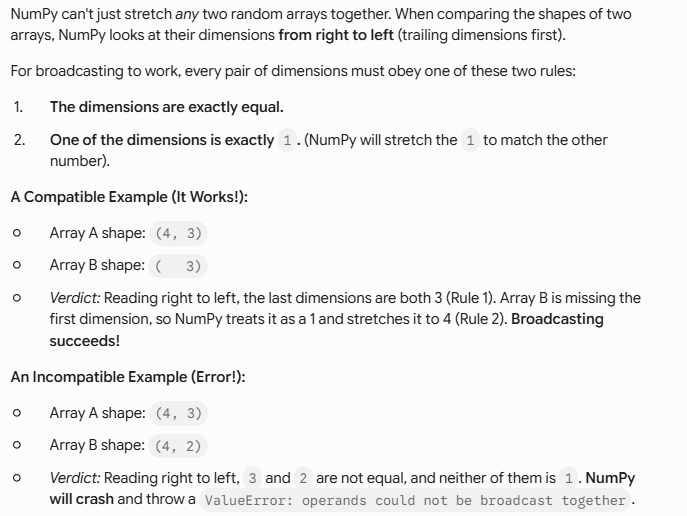

In [5]:
x = np.arange(8)
print(x.shape)    # it will return ( 8, ) it dosent mean 8 rows , in case of 1-D it means 8 columns and 1 row
print(x)

(8,)
[0 1 2 3 4 5 6 7]


Question:
<br>
what about (1,3) and (1,4)
here there is 1 in dimension
<br>
<br>

That is a brilliant question, because it tests exactly how strict NumPy's rules are.

In this specific case, **broadcasting will fail**, and NumPy will throw an error.

Even though there are `1`s present in the shapes, they aren't in the right spot to save the operation. Here is exactly why it breaks down when we apply the Two Golden Rules of broadcasting.

### The Right-to-Left Check

Let's line up your two shapes and check them from right to left, just like NumPy does:

* **Shape A:** `(1, 3)`
* **Shape B:** `(1, 4)`

**Step 1: Check the rightmost dimensions (the columns)**
NumPy looks at the `3` and the `4`.

* Are they equal? No.
* Is one of them a `1`? No.
* **Verdict: CRASH.**

Because the very first check failed, NumPy instantly throws a `ValueError`. It doesn't even bother checking the next dimension (the `1` and `1`), because the operation is already impossible.

### Conceptually: Why does it fail?

Broadcasting only works by *copy-pasting* existing data to fill a space.

If you have a `1`, NumPy can easily stretch it by just repeating that single number. However, if you have a row of 3 numbers (like `[A, B, C]`) and you try to map it onto a row of 4 numbers, NumPy doesn't know what to do. It can line up the first three, but what goes in the fourth slot? It refuses to guess or make up data, so it fails out.

### How to make a 3 and 4 work together

If you wanted to broadcast arrays involving the numbers 3 and 4, you would have to arrange them so that a `1` lines up with the mismatched numbers.

For example, this **will work**:

* **Shape A:** `(3, 1)`  *(3 rows, 1 column)*
* **Shape B:** `(1, 4)`  *(1 row, 4 columns)*

**The Right-to-Left Check here:**

1. **Rightmost:** `1` and `4`. (Passes! Shape A's `1` stretches to become a 4).
2. **Next:** `3` and `1`. (Passes! Shape B's `1` stretches to become a 3).

The result would be a combined `(3, 4)` matrix!